In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
cleveland = pd.read_csv("Cleavland.csv", header=None)
hungary = pd.read_csv("hung.csv", header=None)
switzerland = pd.read_csv("Switzerland.csv", header=None)

# Assign column names
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

cleveland.columns = cols
hungary.columns = cols
switzerland.columns = cols

# Merge all datasets
df = pd.concat([cleveland, hungary, switzerland], ignore_index=True)

# Basic cleaning
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Merged Shape:", df.shape)

Saving Switzerland.csv to Switzerland.csv
Saving hung.csv to hung.csv
Saving Cleavland.csv to Cleavland.csv
Merged Shape: (298, 14)


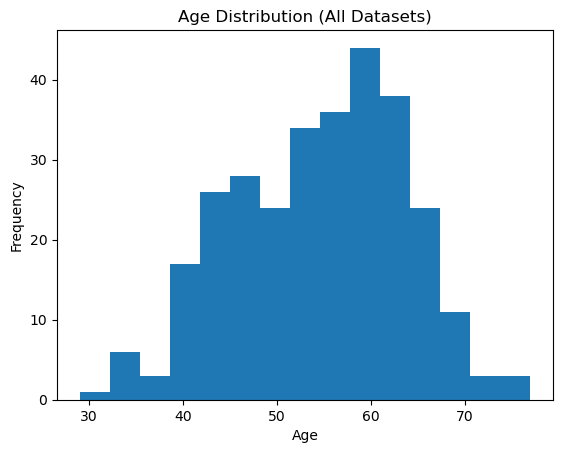

In [ ]:
plt.figure()
plt.hist(df['age'], bins=15)
plt.title("Age Distribution (All Datasets)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

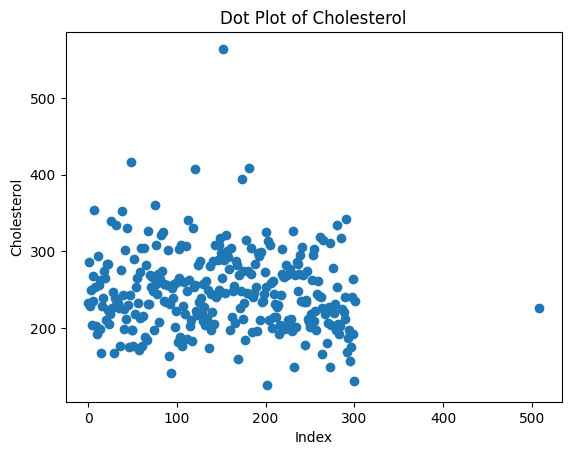

In [4]:
# Dot Plot
plt.figure()

plt.plot(df['chol'], 'o')

plt.title("Dot Plot of Cholesterol")
plt.xlabel("Index")
plt.ylabel("Cholesterol")

plt.show()

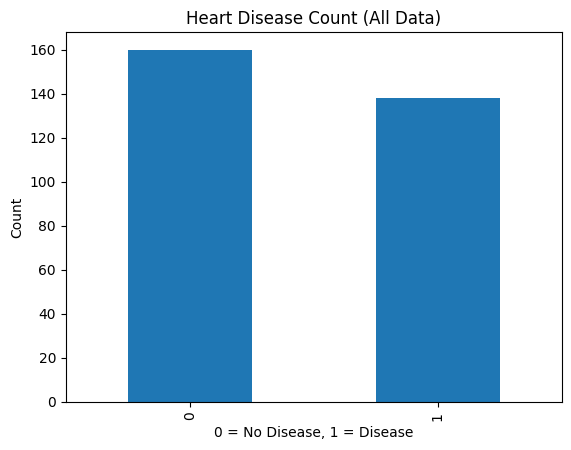

In [5]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Count (All Data)")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

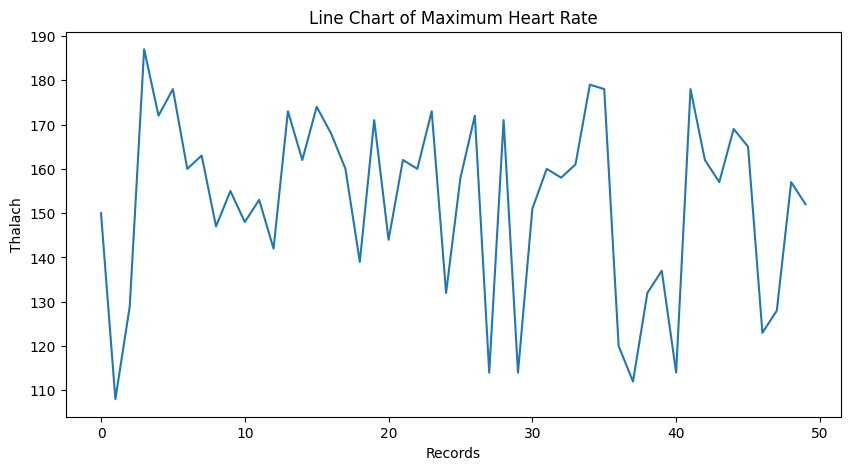

In [6]:

# Line Chart
plt.figure(figsize=(10,5))

plt.plot(df['thalach'].head(50))

plt.title("Line Chart of Maximum Heart Rate")
plt.xlabel("Records")
plt.ylabel("Thalach")

plt.show()

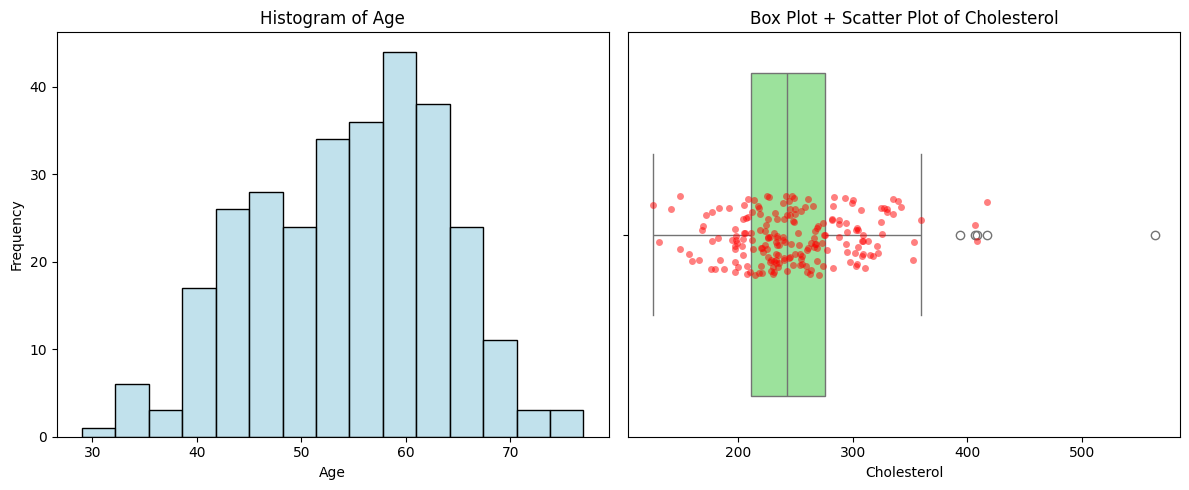

In [7]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ==========================================
# Histogram
# ==========================================

sns.histplot(df['age'],bins=15,color='lightblue',ax=ax1)
ax1.set_title("Histogram of Age")
ax1.set_xlabel("Age")
ax1.set_ylabel("Frequency")

# ==========================================
# Box Plot + Scatter Plot
# ==========================================

# Box Plot
sns.boxplot(x=df['chol'],color='lightgreen',ax=ax2)
# Scatter Plot
sns.stripplot(x=df.sample(200)['chol'],color='red',alpha=0.5,ax=ax2)

ax2.set_title("Box Plot + Scatter Plot of Cholesterol")
ax2.set_xlabel("Cholesterol")

# ==========================================
# Show Plot
# ==========================================

plt.tight_layout()
plt.show()